In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

In [16]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [17]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [18]:
df["TotalCharges"].dtype

dtype('O')

In [19]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()

np.int64(11)

In [20]:
invalid_total_charges = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isna()]

invalid_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [21]:
invalid_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [22]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [23]:
df_clean["TotalCharges"].dtype

dtype('float64')

In [24]:
df_clean["TotalCharges"].isna().sum()

np.int64(0)

In [25]:
df_clean[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].loc[
    df["TotalCharges"].isna() if df["TotalCharges"].isna().any() else []
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [26]:
df_clean.loc[
    df["TotalCharges"].astype(str).str.strip().eq(""),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [27]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
df_clean.duplicated().sum()

np.int64(0)

In [29]:
df_clean.shape

(7043, 21)

In [30]:
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


customerID:
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                

In [31]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

target_column = "Churn"

id_column = "customerID"

In [32]:
print("Numerical columns:", numerical_columns)
print("\nCategorical columns:", categorical_columns)
print("\nTarget column:", target_column)
print("\nID column:", id_column)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target column: Churn

ID column: customerID


In [33]:
print(
    "Total columns accounted for:",
    len(numerical_columns) + len(categorical_columns) + 2
)

Total columns accounted for: 21


In [34]:
df_clean[numerical_columns].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

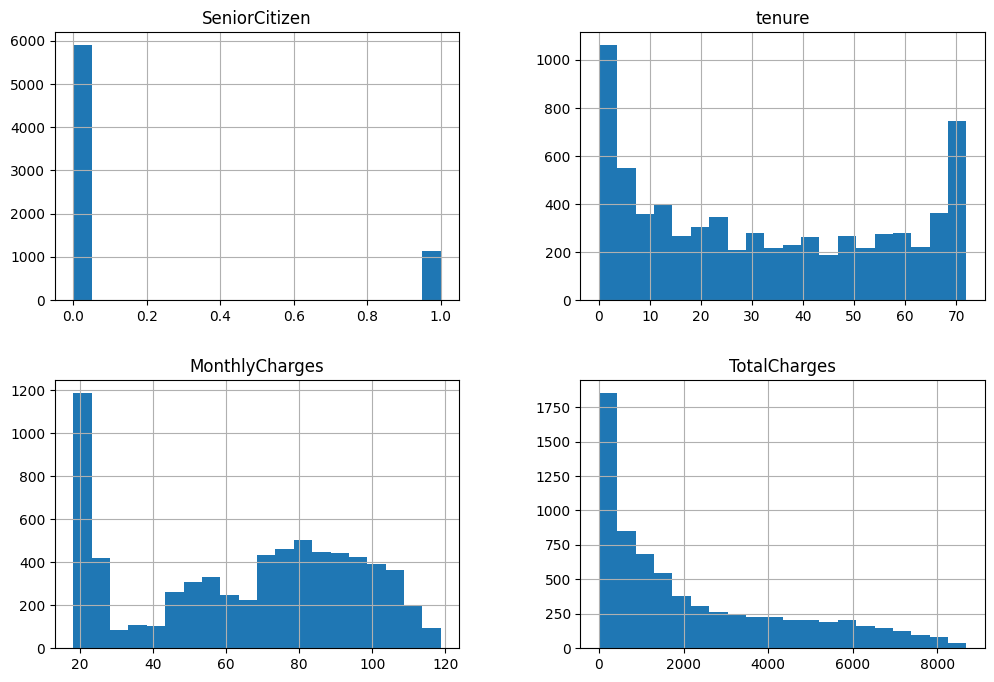

In [35]:
df_clean[numerical_columns].hist(
    figsize=(12, 8),
    bins=20
)

In [36]:
df_clean.groupby("Churn")[numerical_columns].mean()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,0.128721,37.569965,61.265124,2549.911442
Yes,0.254682,17.979133,74.441332,1531.796094


In [37]:
df_clean.groupby("Churn")[numerical_columns].median()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,0.0,38.0,64.425,1679.525
Yes,0.0,10.0,79.650,703.550


In [38]:
categorical_analysis_columns = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "Partner",
    "Dependents"
]

for col in categorical_analysis_columns:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df_clean[col],
            df_clean["Churn"],
            normalize="index"
        ).round(3) * 100
    )


--- Contract ---
Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8

--- InternetService ---
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4

--- PaymentMethod ---
Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1

--- TechSupport ---
Churn                  No   Yes
TechSupport                    
No                   58.4  41.6
No internet service  92.6   7.4
Yes                  84.8  15.2

--- OnlineSecurity ---
Churn                  No   Yes
OnlineSecurity                 
No                   58.2  41.8
No internet service  92.6   7.4
Yes                  85.4  14.6

--- Partner ---
Churn      No   Yes
Partner            
No       

In [39]:
import matplotlib.pyplot as plt

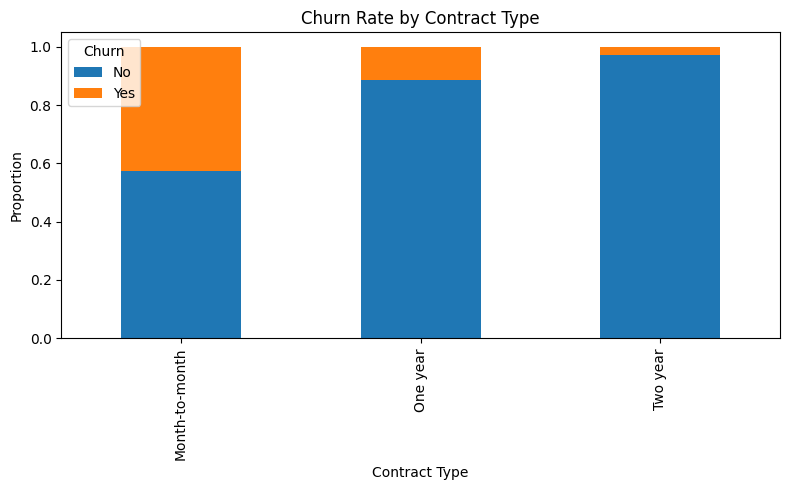

In [40]:
pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Proportion")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [41]:
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [42]:
analysis_columns = [
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

for col in analysis_columns:
    print(f"\n--- {col} ---")
    
    result = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    ) * 100
    
    print(result.round(2))


--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

--- TechSupport ---
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


In [43]:
analysis_columns = [
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

for col in analysis_columns:
    print(f"\n--- {col} ---")
    
    result = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    ) * 100
    
    print(result.round(2))


--- InternetService ---
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

--- PaymentMethod ---
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11

--- TechSupport ---
Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17

--- OnlineSecurity ---
Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


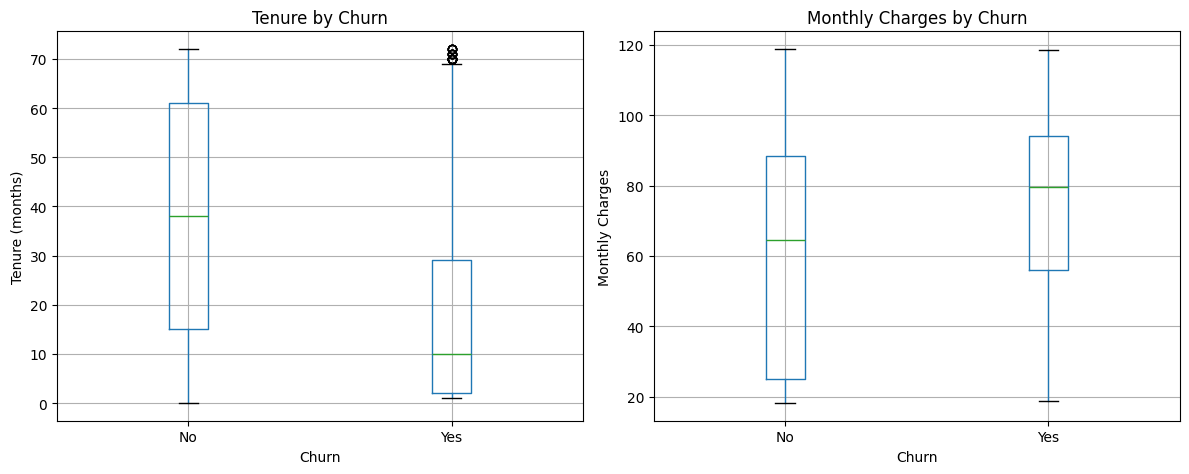

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean.boxplot(
    column="tenure",
    by="Churn",
    ax=axes[0]
)
axes[0].set_title("Tenure by Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Tenure (months)")

df_clean.boxplot(
    column="MonthlyCharges",
    by="Churn",
    ax=axes[1]
)
axes[1].set_title("Monthly Charges by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [45]:
X = df_clean.drop(columns=["Churn", "customerID"])
y = df_clean["Churn"]

In [46]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [47]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [48]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)


In [51]:
print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True) * 100)


Training churn distribution:
Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Testing churn distribution:
Churn
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [54]:
y = y.map({"No": 0, "Yes": 1})

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [56]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [57]:
print(y.dtype)

int64


In [58]:
from sklearn.linear_model import LogisticRegression

In [59]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [60]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
y_pred = logistic_pipeline.predict(X_test)

In [62]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [64]:
logistic_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

logistic_metrics

{'Accuracy': 0.8055358410220014,
 'Precision': 0.6572327044025157,
 'Recall': 0.5588235294117647,
 'F1': 0.6040462427745664,
 'ROC-AUC': 0.8421349040274871}

In [65]:
model_results = []

model_results.append({
    "Model": "Logistic Regression",
    **logistic_metrics
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135


In [66]:
from sklearn.ensemble import RandomForestClassifier

In [67]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [68]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
rf_pred = random_forest_pipeline.predict(X_test)
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [70]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_prob)
}

rf_metrics

{'Accuracy': 0.7835344215755855,
 'Precision': 0.6210526315789474,
 'Recall': 0.4732620320855615,
 'F1': 0.5371775417298937,
 'ROC-AUC': 0.8226898137384071}

In [71]:
model_results.append({
    "Model": "Random Forest",
    **rf_metrics
})

pd.DataFrame(model_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Random Forest,0.783534,0.621053,0.473262,0.537178,0.822690


In [72]:
model_comparison = pd.DataFrame(model_results)
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Random Forest,0.783534,0.621053,0.473262,0.537178,0.822690


In [73]:
from xgboost import XGBClassifier

In [74]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [75]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [77]:
xgb_metrics = {
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

xgb_metrics

{'Accuracy': 0.7984386089425124,
 'Precision': 0.6480263157894737,
 'Recall': 0.5267379679144385,
 'F1': 0.5811209439528023,
 'ROC-AUC': 0.840932341315973}

In [78]:
model_results.append({
    "Model": "XGBoost",
    **xgb_metrics
})

model_comparison = pd.DataFrame(model_results)
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135
1,Random Forest,0.783534,0.621053,0.473262,0.537178,0.822690
2,XGBoost,0.798439,0.648026,0.526738,0.581121,0.840932


In [79]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [80]:
logistic_cv = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

rf_cv = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

xgb_cv = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression:", logistic_cv.mean())
print("Random Forest:", rf_cv.mean())
print("XGBoost:", xgb_cv.mean())

Logistic Regression: 0.8462007441910661
Random Forest: 0.8202956921735138
XGBoost: 0.8436994992586868


In [81]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "CV ROC-AUC Mean": [
        logistic_cv.mean(),
        rf_cv.mean(),
        xgb_cv.mean()
    ],
    "CV ROC-AUC Std": [
        logistic_cv.std(),
        rf_cv.std(),
        xgb_cv.std()
    ]
})

cv_results.sort_values(
    by="CV ROC-AUC Mean",
    ascending=False
)

,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.846201,0.012576
2,XGBoost,0.843699,0.009732
1,Random Forest,0.820296,0.011845


In [82]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Test Accuracy": [
        logistic_metrics["Accuracy"],
        rf_metrics["Accuracy"],
        xgb_metrics["Accuracy"]
    ],
    "Test Precision": [
        logistic_metrics["Precision"],
        rf_metrics["Precision"],
        xgb_metrics["Precision"]
    ],
    "Test Recall": [
        logistic_metrics["Recall"],
        rf_metrics["Recall"],
        xgb_metrics["Recall"]
    ],
    "Test F1": [
        logistic_metrics["F1"],
        rf_metrics["F1"],
        xgb_metrics["F1"]
    ],
    "Test ROC-AUC": [
        logistic_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"],
        xgb_metrics["ROC-AUC"]
    ],
    "CV ROC-AUC Mean": [
        logistic_cv.mean(),
        rf_cv.mean(),
        xgb_cv.mean()
    ],
    "CV ROC-AUC Std": [
        logistic_cv.std(),
        rf_cv.std(),
        xgb_cv.std()
    ]
})

final_model_comparison.sort_values(
    by="CV ROC-AUC Mean",
    ascending=False
)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.842135,0.846201,0.012576
2,XGBoost,0.798439,0.648026,0.526738,0.581121,0.840932,0.843699,0.009732
1,Random Forest,0.783534,0.621053,0.473262,0.537178,0.822690,0.820296,0.011845


In [83]:
import mlflow
import mlflow.sklearn

In [84]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

In [85]:
mlflow.set_experiment(
    experiment_name="customer-churn-modeling"
)

<Experiment: artifact_location=('file:///d:/daily '
 'folder/placement/Projects/ML-Lifecycle-Model-Monitoring/notebooks/mlruns/1'), creation_time=1787727062666, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787727062666, lifecycle_stage='active', name='customer-churn-modeling', tags={}, trace_location=None, workspace='default'>

In [86]:
experiment = mlflow.get_experiment_by_name(
    "customer-churn-modeling"
)

print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Tracking URI:", mlflow.get_tracking_uri())

Experiment name: customer-churn-modeling
Experiment ID: 1
Tracking URI: sqlite:///../mlflow.db


In [87]:
with mlflow.start_run(run_name="logistic-regression-baseline"):

    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("accuracy", logistic_metrics["Accuracy"])
    mlflow.log_metric("precision", logistic_metrics["Precision"])
    mlflow.log_metric("recall", logistic_metrics["Recall"])
    mlflow.log_metric("f1", logistic_metrics["F1"])
    mlflow.log_metric("roc_auc", logistic_metrics["ROC-AUC"])

    mlflow.sklearn.log_model(
        logistic_pipeline,
        name="logistic_regression_model"
    )

    print("Logistic Regression run logged successfully.")

Logistic Regression run logged successfully.


In [88]:
with mlflow.start_run(run_name="random-forest-baseline"):

    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", rf_metrics["Accuracy"])
    mlflow.log_metric("precision", rf_metrics["Precision"])
    mlflow.log_metric("recall", rf_metrics["Recall"])
    mlflow.log_metric("f1", rf_metrics["F1"])
    mlflow.log_metric("roc_auc", rf_metrics["ROC-AUC"])

    mlflow.sklearn.log_model(
        random_forest_pipeline,
        name="random_forest_model"
    )

    print("Random Forest run logged successfully.")

Random Forest run logged successfully.


In [89]:
with mlflow.start_run(run_name="xgboost-baseline"):

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("subsample", 0.8)
    mlflow.log_param("colsample_bytree", 0.8)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("accuracy", xgb_metrics["Accuracy"])
    mlflow.log_metric("precision", xgb_metrics["Precision"])
    mlflow.log_metric("recall", xgb_metrics["Recall"])
    mlflow.log_metric("f1", xgb_metrics["F1"])
    mlflow.log_metric("roc_auc", xgb_metrics["ROC-AUC"])

    print("XGBoost metrics logged successfully.")

XGBoost metrics logged successfully.


In [90]:
runs = mlflow.search_runs(
    experiment_names=["customer-churn-modeling"]
)

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1",
        "metrics.roc_auc"
    ]
]

,run_id,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc
0,20f621679df8479e948b971ac8404fa8,xgboost-baseline,0.798439,0.648026,0.526738,0.581121,0.840932
1,89c0b8f6746149c1a41587acd964fd9e,random-forest-baseline,0.783534,0.621053,0.473262,0.537178,0.822690
2,da14d38081db49ea8c5ebee1e186d161,logistic-regression-baseline,0.805536,0.657233,0.558824,0.604046,0.842135
3,b9f923f4109a430c8ba376b6d1408f47,logistic-regression-production,NaN,NaN,NaN,NaN,NaN
4,6ed4d5100b1d46f29b56906a9238ba0e,xgboost-baseline,0.798439,0.648026,0.526738,0.581121,0.840932
5,75a1f19c597b4ef98832ffb28f618069,xgboost-baseline,0.798439,0.648026,0.526738,0.581121,0.840932
6,1927aa0b59724ff88ceb9291651eff1f,random-forest-baseline,0.783534,0.621053,0.473262,0.537178,0.822690
7,a9e26aff125a46fd8c960363d05638df,logistic-regression-baseline,0.805536,0.657233,0.558824,0.604046,0.842135


In [91]:
runs = mlflow.search_runs(
    experiment_names=["customer-churn-modeling"]
)

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.precision",
        "metrics.recall",
        "metrics.f1",
        "metrics.roc_auc"
    ]
]

,run_id,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc
0,20f621679df8479e948b971ac8404fa8,xgboost-baseline,0.798439,0.648026,0.526738,0.581121,0.840932
1,89c0b8f6746149c1a41587acd964fd9e,random-forest-baseline,0.783534,0.621053,0.473262,0.537178,0.822690
2,da14d38081db49ea8c5ebee1e186d161,logistic-regression-baseline,0.805536,0.657233,0.558824,0.604046,0.842135
3,b9f923f4109a430c8ba376b6d1408f47,logistic-regression-production,NaN,NaN,NaN,NaN,NaN
4,6ed4d5100b1d46f29b56906a9238ba0e,xgboost-baseline,0.798439,0.648026,0.526738,0.581121,0.840932
5,75a1f19c597b4ef98832ffb28f618069,xgboost-baseline,0.798439,0.648026,0.526738,0.581121,0.840932
6,1927aa0b59724ff88ceb9291651eff1f,random-forest-baseline,0.783534,0.621053,0.473262,0.537178,0.822690
7,a9e26aff125a46fd8c960363d05638df,logistic-regression-baseline,0.805536,0.657233,0.558824,0.604046,0.842135


In [92]:
with mlflow.start_run(run_name="logistic-regression-production"):

    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("selection_reason", "Best overall test and cross-validation performance")

    mlflow.log_metric("test_accuracy", logistic_metrics["Accuracy"])
    mlflow.log_metric("test_precision", logistic_metrics["Precision"])
    mlflow.log_metric("test_recall", logistic_metrics["Recall"])
    mlflow.log_metric("test_f1", logistic_metrics["F1"])
    mlflow.log_metric("test_roc_auc", logistic_metrics["ROC-AUC"])

    mlflow.log_metric("cv_roc_auc_mean", logistic_cv.mean())
    mlflow.log_metric("cv_roc_auc_std", logistic_cv.std())

    model_info = mlflow.sklearn.log_model(
        logistic_pipeline,
        name="customer_churn_model"
    )

    print("Production model logged successfully.")

Production model logged successfully.


In [93]:
registered_model = mlflow.register_model(
    model_uri=model_info.model_uri,
    name="CustomerChurnModel"
)

print("Model name:", registered_model.name)
print("Model version:", registered_model.version)

Registered model 'CustomerChurnModel' already exists. Creating a new version of this model...
Created version '2' of model 'CustomerChurnModel'.


Model name: CustomerChurnModel
Model version: 2


In [94]:
import mlflow.sklearn

production_model_uri = "models:/CustomerChurnModel/1"

loaded_model = mlflow.sklearn.load_model(
    production_model_uri
)

print("Production model loaded successfully.")

Production model loaded successfully.


In [95]:
sample_customer = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_customer)[0]
probability = loaded_model.predict_proba(sample_customer)[0, 1]

print("Predicted class:", prediction)
print("Churn probability:", round(probability * 100, 2), "%")

Predicted class: 0
Churn probability: 4.59 %


In [96]:
original_prediction = logistic_pipeline.predict(sample_customer)[0]
loaded_prediction = loaded_model.predict(sample_customer)[0]

print("Original model prediction:", original_prediction)
print("Loaded model prediction  :", loaded_prediction)

Original model prediction: 0
Loaded model prediction  : 0


In [97]:
sample_customer_api = df_clean.drop(columns=["Churn", "customerID"]).iloc[0]

sample_customer_api

gender                        Female
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                             1
PhoneService                      No
MultipleLines       No phone service
InternetService                  DSL
OnlineSecurity                    No
OnlineBackup                     Yes
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 29.85
TotalCharges                   29.85
Name: 0, dtype: object

In [98]:
sample_customer_api.to_dict()

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'No',
 'tenure': 1,
 'PhoneService': 'No',
 'MultipleLines': 'No phone service',
 'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'No',
 'StreamingTV': 'No',
 'StreamingMovies': 'No',
 'Contract': 'Month-to-month',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Electronic check',
 'MonthlyCharges': 29.85,
 'TotalCharges': 29.85}

In [99]:
import mlflow

In [100]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")

model_version = mlflow.MlflowClient().get_model_version(
    name="CustomerChurnModel",
    version="1"
)

print("Model name:", model_version.name)
print("Model version:", model_version.version)
print("Model source:", model_version.source)

Model name: CustomerChurnModel
Model version: 1
Model source: models:/m-17003538caa44c1caa6251c46ff3c5d9


In [101]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")

client = mlflow.MlflowClient()

model_version = client.get_model_version(
    name="CustomerChurnModel",
    version="1"
)

print("Model name:", model_version.name)
print("Model version:", model_version.version)
print("Model source:", model_version.source)
print("Tracking URI:", mlflow.get_tracking_uri())

Model name: CustomerChurnModel
Model version: 1
Model source: models:/m-17003538caa44c1caa6251c46ff3c5d9
Tracking URI: sqlite:///../mlflow.db


In [102]:
print("Registered model URI:", "models:/CustomerChurnModel/1")

Registered model URI: models:/CustomerChurnModel/1


In [103]:
print("Model source:", model_version.source)

Model source: models:/m-17003538caa44c1caa6251c46ff3c5d9


In [104]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")

client = mlflow.MlflowClient()

model_version = client.get_model_version(
    name="CustomerChurnModel",
    version="1"
)

print("Model name:", model_version.name)
print("Version:", model_version.version)
print("Source:", model_version.source)
print("Run ID:", model_version.run_id)

Model name: CustomerChurnModel
Version: 1
Source: models:/m-17003538caa44c1caa6251c46ff3c5d9
Run ID: b9f923f4109a430c8ba376b6d1408f47


In [105]:
logged_model = client.get_logged_model(
    model_version.source.replace("models:/", "")
)

print(logged_model)

LoggedModel(artifact_location='file:///d:/daily folder/placement/Projects/ML-Lifecycle-Model-Monitoring/notebooks/mlruns/1/models/m-17003538caa44c1caa6251c46ff3c5d9/artifacts', creation_timestamp=1787815664232, experiment_id='1', last_updated_timestamp=1787815721659, model_id='m-17003538caa44c1caa6251c46ff3c5d9', model_type=None, model_uri='models:/m-17003538caa44c1caa6251c46ff3c5d9', name='customer_churn_model', source_run_id='b9f923f4109a430c8ba376b6d1408f47', status=<LoggedModelStatus.READY: 'READY'>, status_message=None)


In [106]:
from pathlib import Path
import mlflow.sklearn

model_path = Path("../models/customer_churn_model_v1")

deployment_model = mlflow.sklearn.load_model(
    str(model_path)
)

print("Deployment model loaded successfully.")

Deployment model loaded successfully.


In [107]:
# Recreate the feature/target split
X = df_clean.drop(columns=["Churn", "customerID"])
y = df_clean["Churn"].map({"No": 0, "Yes": 1})

# Recreate the same train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [108]:
deployment_prediction = deployment_model.predict(
    X_test.iloc[[0]]
)[0]

deployment_probability = deployment_model.predict_proba(
    X_test.iloc[[0]]
)[0, 1]

print("Prediction:", deployment_prediction)
print("Probability:", round(float(deployment_probability), 4))

Prediction: 0
Probability: 0.0459


In [109]:
from pathlib import Path

reference_path = Path("../data/reference_data.csv")

X_train.to_csv(
    reference_path,
    index=False
)

print("Reference dataset saved to:", reference_path)
print("Reference shape:", X_train.shape)

Reference dataset saved to: ..\data\reference_data.csv
Reference shape: (5634, 19)
